# Odd Scenarios

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import math
import soundfile as sf
import random
from tqdm.notebook import tqdm as tqdm

In [2]:
pickle_file = "beta_zeroone.pth"
beta  = "0.02"

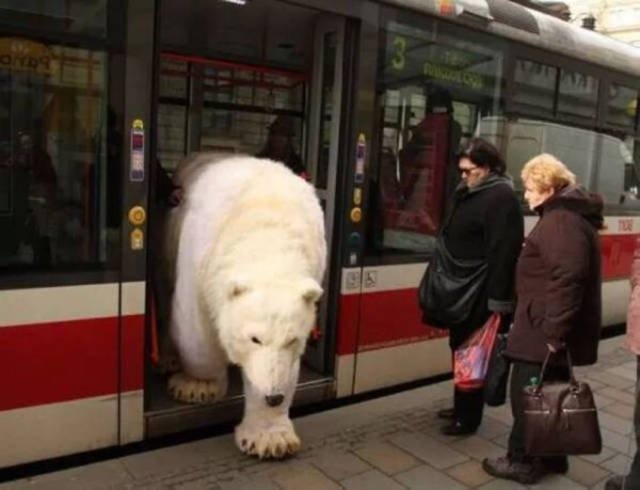

In [3]:
from IPython.display import Image
Image("bear.jpg")

In [4]:
device="cpu" 

In [5]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [6]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

In [7]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t

In [8]:
input_length = 256
x1, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=500, amplitude=1)
x2, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=700, amplitude=1)

## 1.Linearly interpolating between shapes

In [9]:
def linear_interpolate_waveforms(x1, x2, lambda_val):
    interpolated_waveforms = []
    for t in np.linspace(0, 1, lambda_val):
        interpolated_waveform = (1 - t) * x1 + t * x2
        interpolated_waveforms.append(interpolated_waveform)
    return interpolated_waveforms

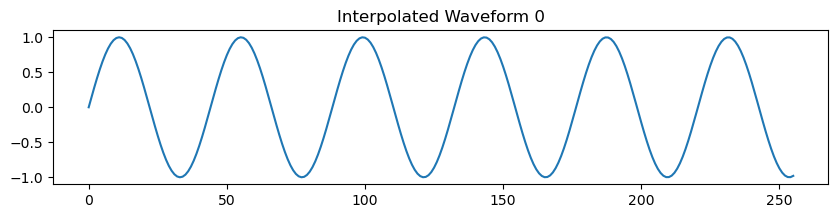

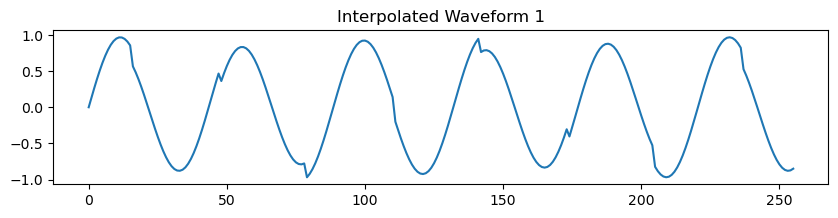

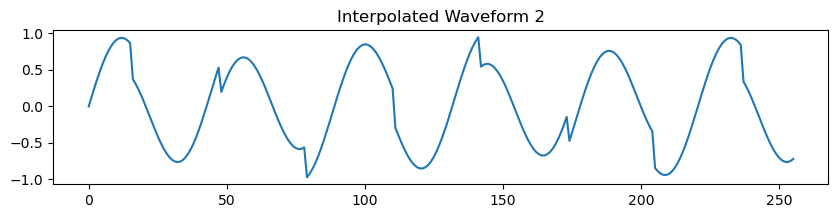

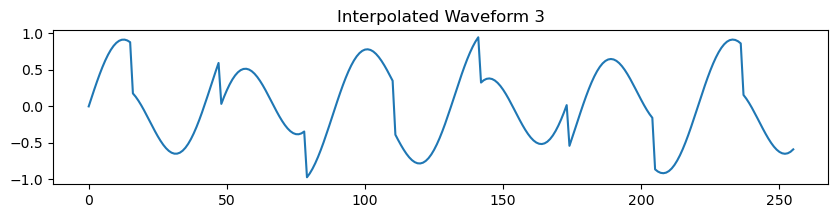

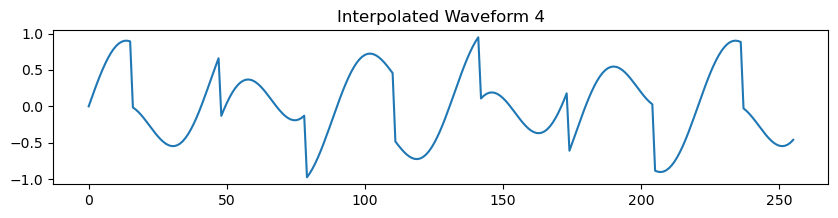

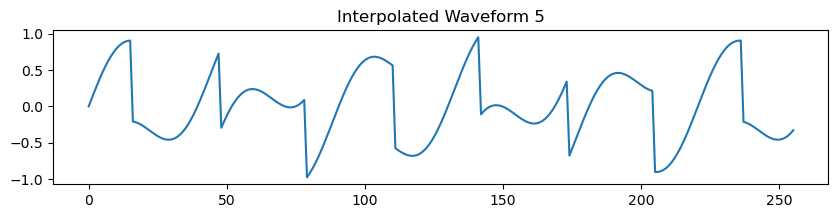

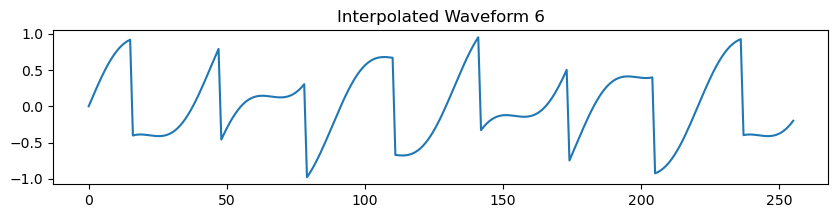

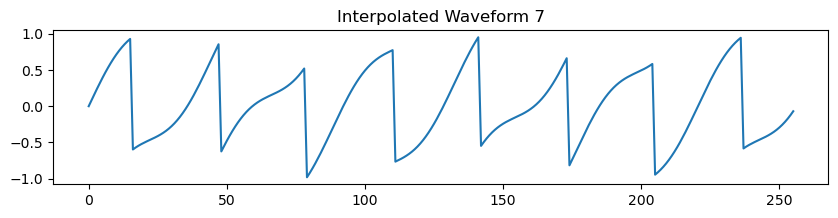

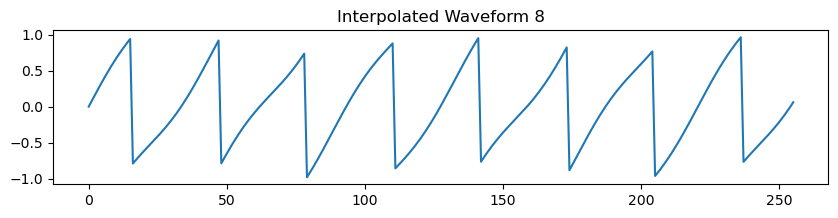

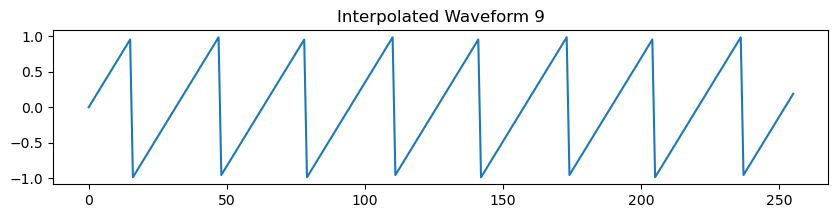

In [10]:
lambda_val = 10
interpolated_waveforms = linear_interpolate_waveforms(x1, x2, lambda_val)
for i, wave in enumerate(interpolated_waveforms):
    plt.figure(figsize=(10, 2))
    plt.plot(wave[0])
    plt.title(f'Interpolated Waveform {i}')
    plt.show()

In [11]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128, 64, 36]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1],hidden_dims[2]),
            torch.nn.Tanh(),
            
        )

        self.z_mean = torch.nn.Linear(hidden_dims[2], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[2], latent_dim)


        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded

In [12]:
autoencoder = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
autoencoder.load_state_dict(torch.load(pickle_file))

<All keys matched successfully>

In [13]:
z1 = autoencoder.encoder(torch.Tensor(x1))
z2 = autoencoder.encoder(torch.Tensor(x2))

In [14]:
interpolated_enocoded_waveforms = linear_interpolate_waveforms(z1, z2, lambda_val)

In [15]:
len(interpolated_enocoded_waveforms)

10

In [16]:
decoded_wav = []
for wav in interpolated_enocoded_waveforms:
    z_mean, z_log_var = autoencoder.z_mean(wav), autoencoder.z_log_var(wav)
    encoded = autoencoder.reparameterize(z_mean, z_log_var)
    decoded = autoencoder.decoder(encoded)
    decoded_wav.append(decoded)

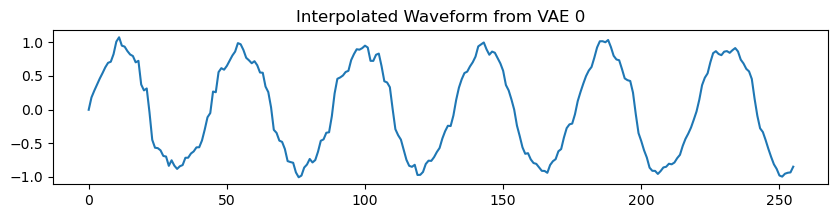

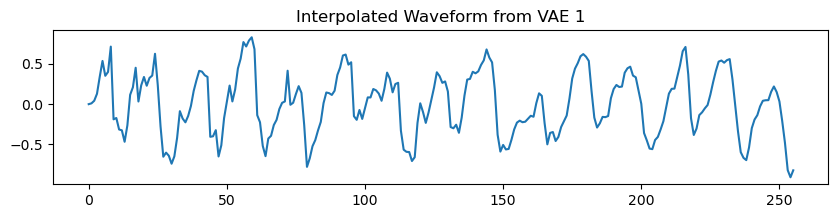

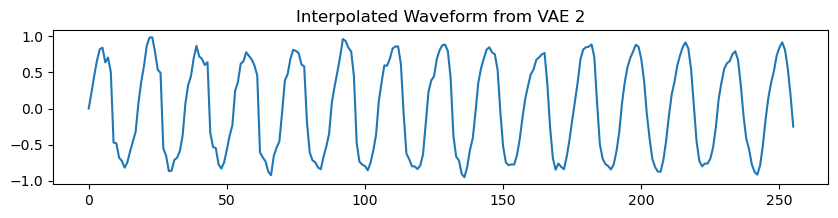

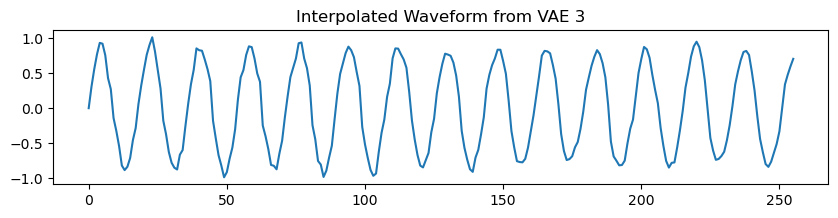

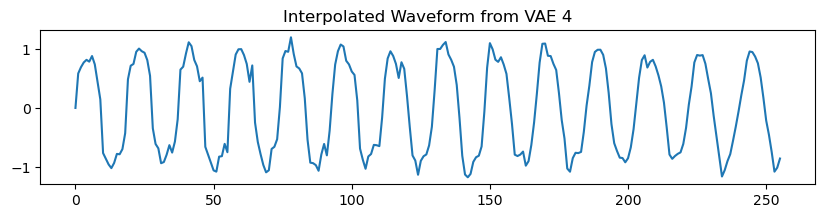

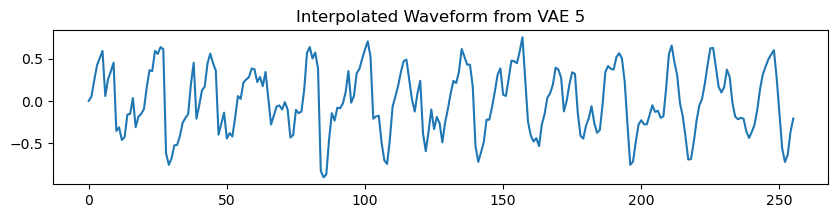

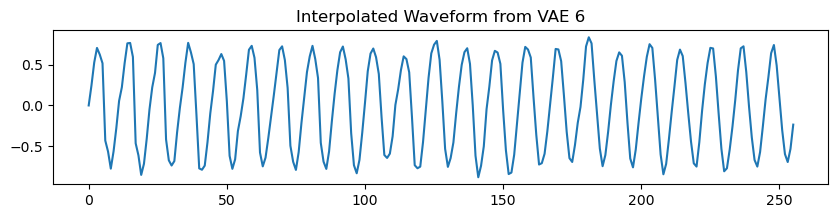

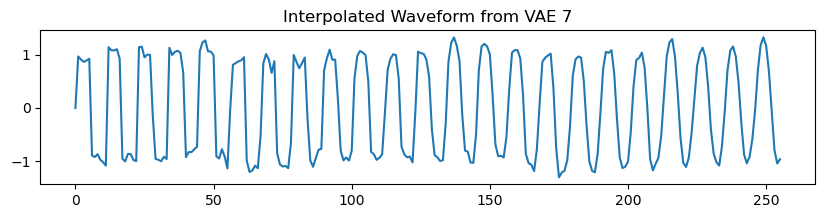

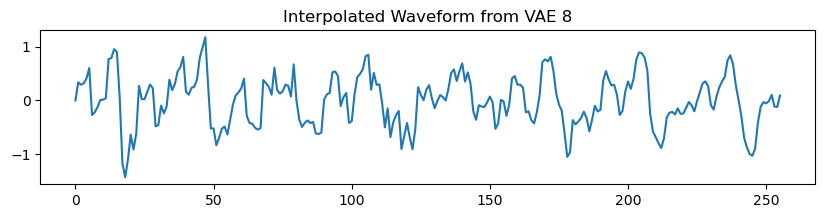

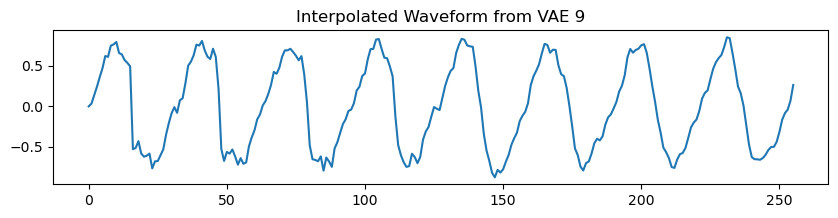

In [17]:
for i, wave in enumerate(decoded_wav):
    plt.figure(figsize=(10, 2))
    plt.plot(wave[0].detach().numpy())
    plt.title(f'Interpolated Waveform from VAE {i}')
    plt.show()

## Linearly Interpolatin between periods

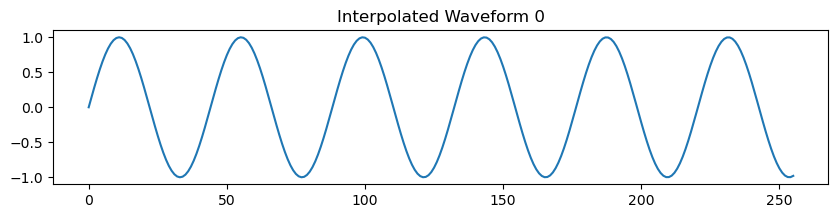

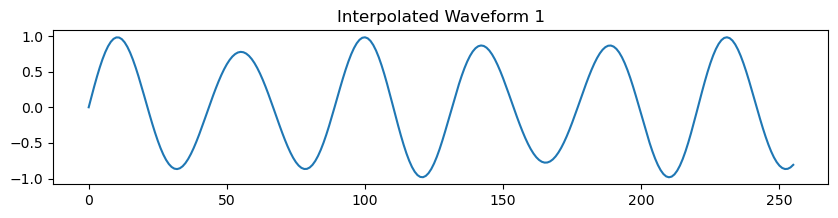

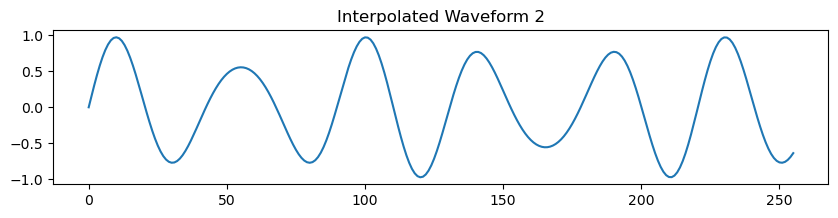

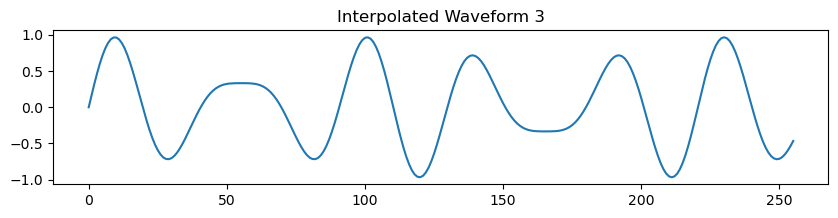

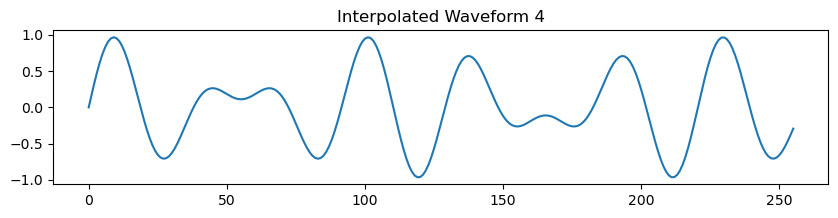

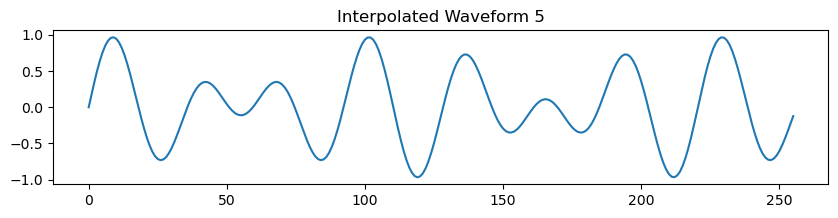

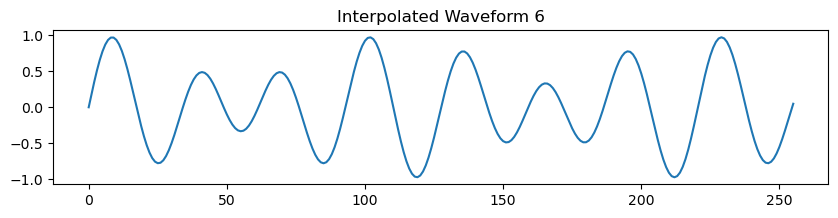

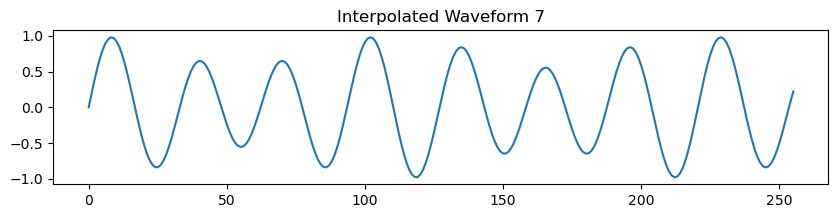

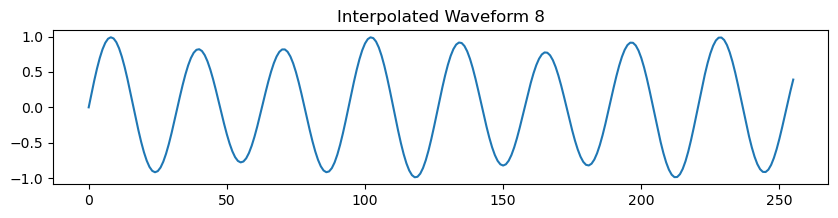

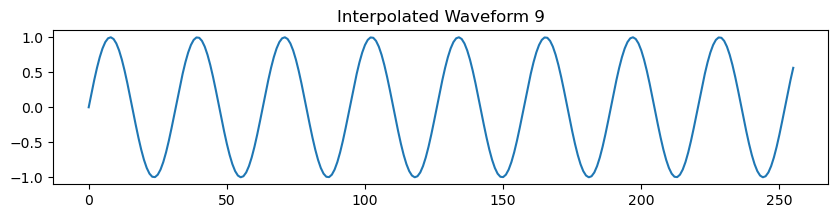

In [18]:
lambda_val = 10
x1, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=500, amplitude=1)
x2, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=700, amplitude=1)
interpolated_waveforms = linear_interpolate_waveforms(x1, x2, lambda_val)
for i, wave in enumerate(interpolated_waveforms):
    plt.figure(figsize=(10, 2))
    plt.plot(wave[0])
    plt.title(f'Interpolated Waveform {i}')
    plt.show()

In [19]:
z1 = autoencoder.encoder(torch.Tensor(x1))
z2 = autoencoder.encoder(torch.Tensor(x2))

In [20]:
interpolated_enocoded_waveforms = linear_interpolate_waveforms(z1, z2, lambda_val)

In [21]:
decoded_wav = []
for wav in interpolated_enocoded_waveforms:
    z_mean, z_log_var = autoencoder.z_mean(wav), autoencoder.z_log_var(wav)
    encoded = autoencoder.reparameterize(z_mean, z_log_var)
    decoded = autoencoder.decoder(encoded)
    decoded_wav.append(decoded)

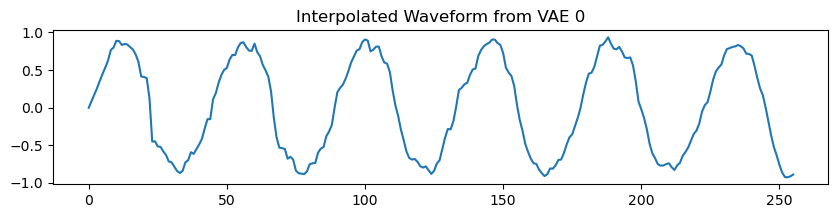

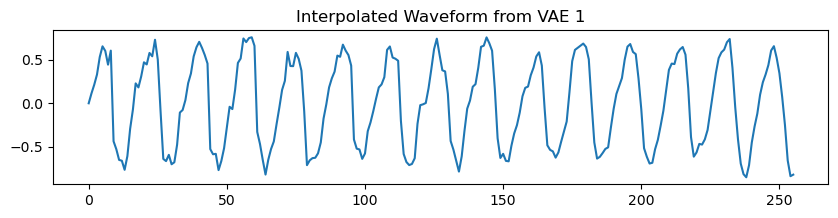

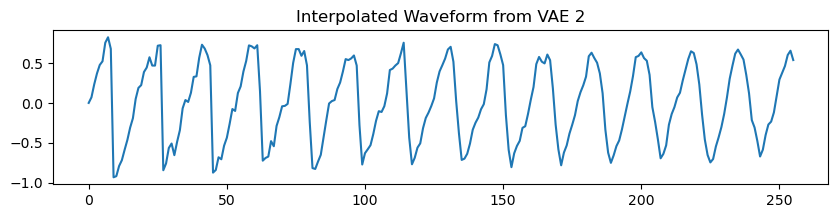

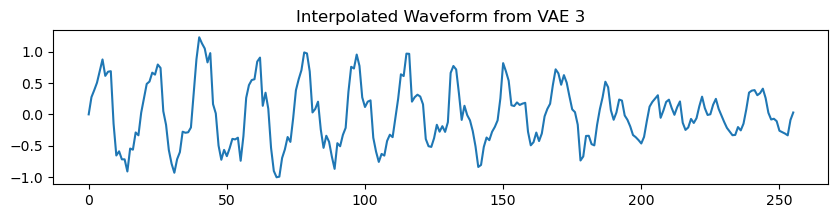

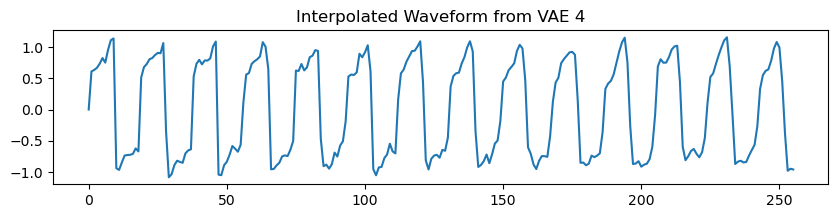

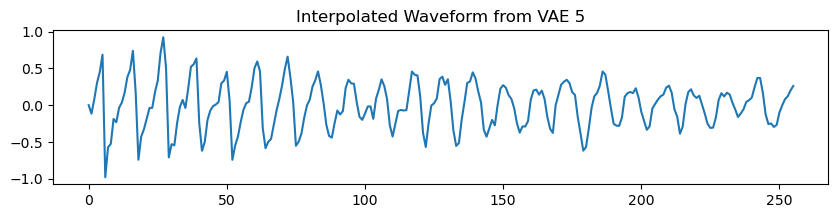

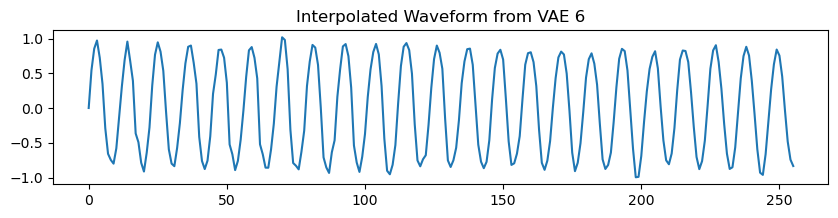

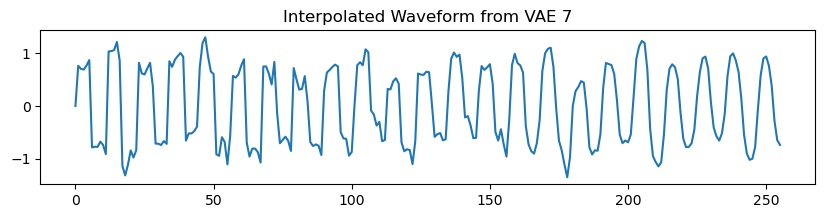

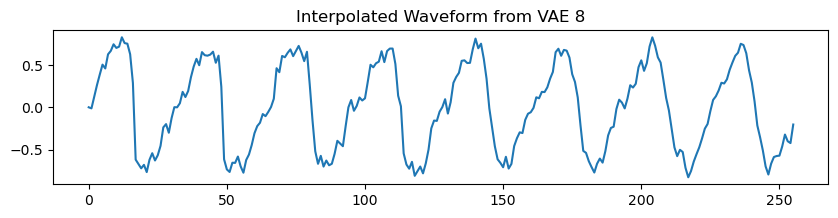

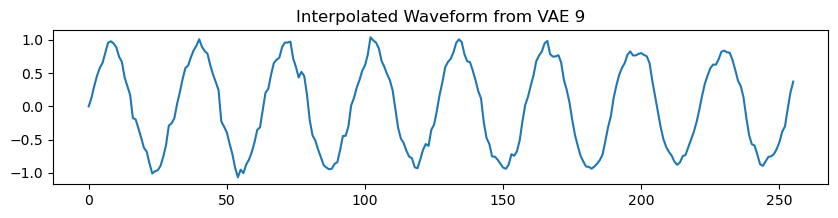

In [22]:
for i, wave in enumerate(decoded_wav):
    plt.figure(figsize=(10, 2))
    plt.plot(wave[0].detach().numpy())
    plt.title(f'Interpolated Waveform from VAE {i}')
    plt.show()

## 2. Amplitude Variation

In [23]:
input_length = 256
amplitudes = [0,0.25,0.5, 1.0, 1.5,2.0]
x1_amplitude_var, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=100, amplitude=amplitudes)

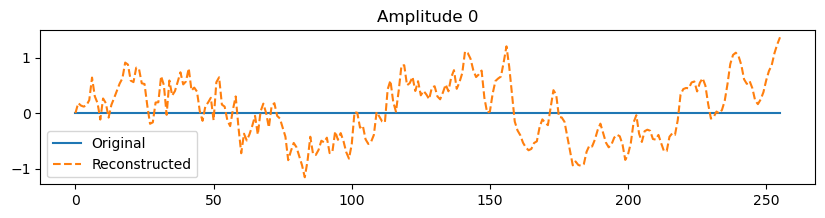

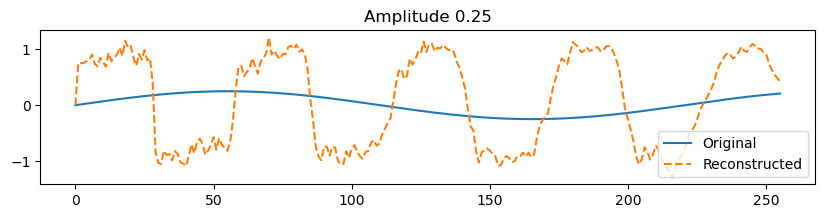

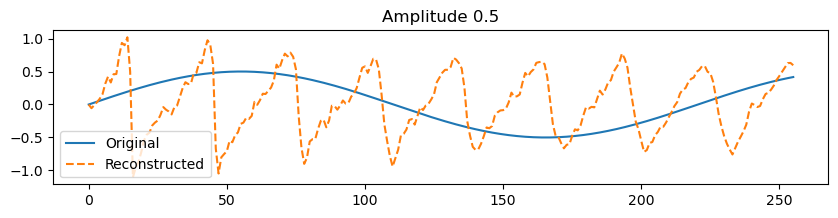

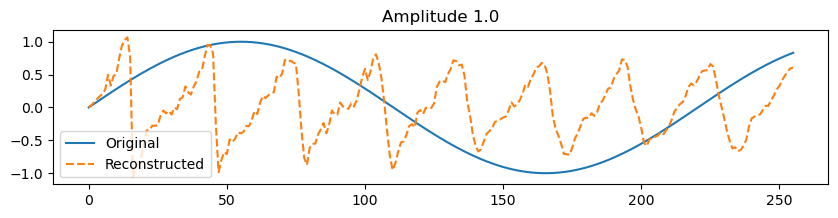

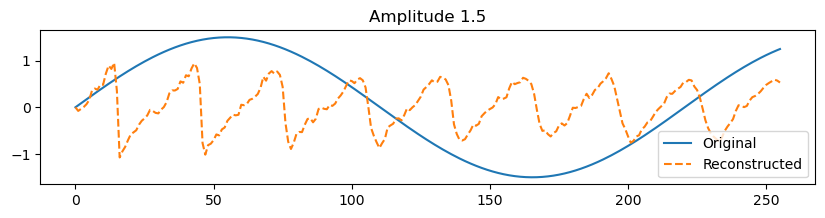

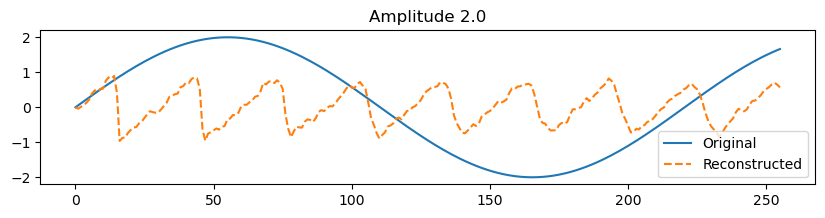

In [24]:
z1 = autoencoder.encoder(torch.Tensor(x1_amplitude_var))
z_mean, z_log_var = autoencoder.z_mean(torch.Tensor(z1)), autoencoder.z_log_var(torch.Tensor(z1))
encoded = autoencoder.reparameterize(z_mean, z_log_var)
decoded = autoencoder.decoder(encoded)
decoded_wav = decoded.detach().numpy()
for i, (original, reconstructed) in enumerate(zip(x1_amplitude_var, decoded_wav)):
    plt.figure(figsize=(10, 2))
    plt.plot(original, label='Original')
    plt.plot(reconstructed, label='Reconstructed', linestyle='--')
    plt.title(f'Amplitude {amplitudes[i]}')
    plt.legend()
    plt.show()


## 3. Denoising ? 

In [25]:
x1, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=100, amplitude=1)
noise_levels = [0.01, 0.1, 0.5,2.0]
noisy_waves = [x1 + noise * np.random.randn(*x1.shape) for noise in noise_levels]
noisy_waves = np.squeeze(np.array(noisy_waves))

In [26]:
noisy_waves.shape

(4, 256)

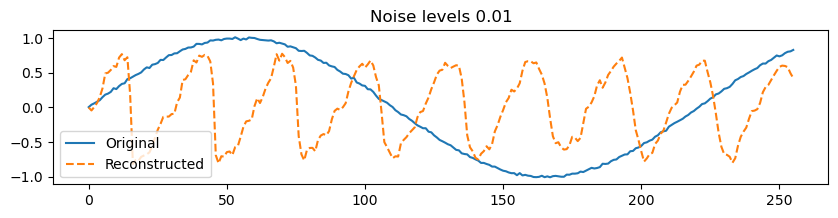

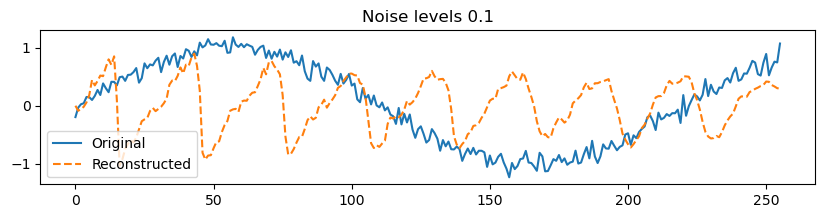

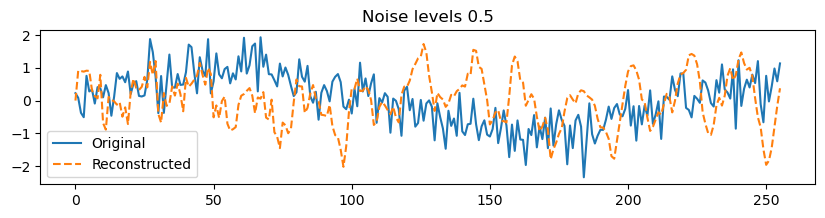

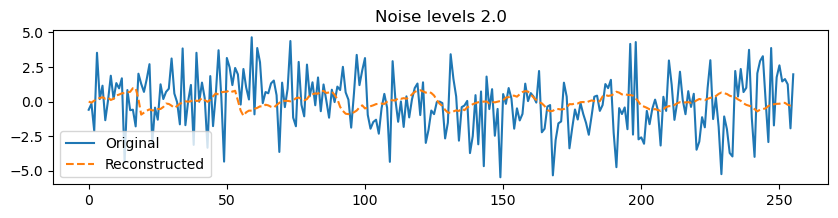

In [27]:
z1 = autoencoder.encoder(torch.Tensor(noisy_waves))
z_mean, z_log_var = autoencoder.z_mean(torch.Tensor(z1)), autoencoder.z_log_var(torch.Tensor(z1))
encoded = autoencoder.reparameterize(z_mean, z_log_var)
decoded = autoencoder.decoder(encoded)
decoded_wav = decoded.detach().numpy()
for i, (original, reconstructed) in enumerate(zip(noisy_waves, decoded_wav)):
    plt.figure(figsize=(10, 2))
    plt.plot(original, label='Original')
    plt.plot(reconstructed, label='Reconstructed', linestyle='--')
    plt.title(f'Noise levels {noise_levels[i]}')
    plt.legend()
    plt.show()
